### 📊 **ERA5 vs 지상 관측값: 지점 단위 비교**

---

# 📝 **소개**

이 노트북에서는 **ERA5 재분석 데이터**와 실제 **지상 관측소 관측값**을 한국 지역을 중심으로 비교합니다.

선택한 관측소 위치에서 가장 가까운 ERA5 데이터를 추출하여, 얼마나 잘 일치하는지 확인해볼 것입니다.

---

## 🚀 **무엇을 하게 될까요?**

1. **관측소 데이터 불러오기**  
   - 지상 관측소(AWS 등)의 위도/경도 정보를 사용합니다.

2. **ERA5 데이터에서 인근 격자 추출**  
   - 각 관측소에 가장 가까운 ERA5 격자점을 찾습니다  
   - NetCDF 파일에서 2m 기온(`T2M`) 데이터를 추출합니다

3. **비교 및 시각화**  
   - 시간대를 맞춰 데이터를 비교합니다  
   - 시계열 그래프를 그리고 차이(예: 편향, RMSE 등)를 확인합니다

---

자, 이제 시작해볼까요? 🚀


# ⚙️ **1. Set-up**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import netCDF4 as nc

import matplotlib.pyplot as plt

# **2. 지상 관측 데이터 불러오기**

In [ ]:
# 관측 지점의 위도와 경도 설정 (예시: 서울 부근)
df_lat, df_lon = 37.57142000, 126.96580000

# 기상청 관측 데이터를 CSV 파일에서 불러오기
df = pd.read_csv(
    '/content/drive/MyDrive/Weather_BigData/kma_temp_202404.csv',
    encoding='euc-kr',          # 파일 인코딩 형식이 EUC-KR (기상청 자료에 주로 사용됨)
    comment='#',                # '#'으로 시작하는 줄은 주석으로 간주하고 무시함
    sep=r'\s+',                 # 공백(스페이스, 탭 등)으로 구분된 데이터를 읽기 위해 정규표현식 사용
    header=None,                # 첫 번째 줄을 헤더로 사용하지 않음 (직접 열 이름을 지정함)
    index_col=0,                # 첫 번째 열(STN, 지점 번호)을 인덱스로 사용
    parse_dates=True,           # 인덱스 열에 날짜/시간 정보가 있으면 자동으로 datetime 형식으로 변환
    names=['STN','LON','LAT','HT','TEMP'], # 열 이름을 수동으로 지정
    on_bad_lines='skip'         # 열 수가 맞지 않는 잘못된 줄은 건너뜀
)

print(df[:5]) # 데이터프레임의 처음 5줄 출력
print(df.shape) # 전체 데이터의 행과 열 개수 출력

### 시간 단위 기온 데이터를 일 단위 평균으로 변환
# (예: 하루 동안의 시간별 온도를 하루 평균으로 집계)
df.index = df.index - pd.Timedelㅋta(hours=9)
# → 이 줄은 UTC 기준 시간을 KST(한국 시간)으로 맞추기 위해 9시간을 뺄 때 사용 (주석 처리된 상태)

daily_df = df.resample('D').mean()
print(daily_df[:5])
print(daily_df.shape)


                     STN       LON       LAT     HT  TEMP
2024-04-01 00:00:00  108  126.9658  37.57142  85.67   9.5
2024-04-01 01:00:00  108  126.9658  37.57142  85.67   8.6
2024-04-01 02:00:00  108  126.9658  37.57142  85.67   7.7
2024-04-01 03:00:00  108  126.9658  37.57142  85.67   7.2
2024-04-01 04:00:00  108  126.9658  37.57142  85.67   6.7
(720, 5)
              STN       LON       LAT     HT       TEMP
2024-03-31  108.0  126.9658  37.57142  85.67   7.233333
2024-04-01  108.0  126.9658  37.57142  85.67  12.412500
2024-04-02  108.0  126.9658  37.57142  85.67  17.241667
2024-04-03  108.0  126.9658  37.57142  85.67  16.037500
2024-04-04  108.0  126.9658  37.57142  85.67  15.387500
(31, 5)


# **3. 재분석 데이터(ERA5) 추출하기**

In [ ]:
#NC 파일을 안 받았을 때 코드. 받았으면 아래 코드 실행하면됨

# 만약 Google Drive에 .nc 파일(NetCDF 형식 기상 데이터 파일)이
# 없다면 아래 코드를 통해 좌표 매칭 연습을 할 수 있음

# 기상 관측소 위치 (서울 부근, 예시 좌표)
df_lat, df_lon = 37.57142000, 126.96580000

# ERA5에서 사용되는 위도(latitudes): 90도(북극)부터 -90도(남극)까지 0.25도 간격으로 생성
lats = np.arange(90, -91, -0.25)

# ERA5에서 사용되는 경도(longitudes): -180도(서경)부터 180도(동경)까지 0.25도 간격으로 생성
lons = np.arange(-180, 180, 0.25)

# 🔍 ERA5 격자 중 관측소 위치와 가장 가까운 위도 인덱스를 찾기
lat_idx =  np.abs(lats - df_lat).argmin() #argmin -> 가장 작은 값의 인덱스 반환
lon_idx =  np.abs(lons - df_lon).argmin()

# 📍 찾은 인덱스를 통해 ERA5에서 가장 가까운 실제 위도 값 추출
nearest_lat = lats[lat_idx]
nearest_lon = lons[lon_idx]

210
1228


In [ ]:
path1 = "/content/drive/MyDrive/Weather_BigData/era5_t2m_202404.nc"  # 📁 사용할 ERA5 데이터(.nc 파일) 경로

with nc.Dataset(path1, mode='r') as dataset:  # 🔓 NetCDF 파일 열기 (읽기 모드)

    # 📌 위도, 경도, 시간 정보 추출
    times = dataset.variables['valid_time']  # 시간 정보 (숫자로 저장됨 → 나중에 날짜로 변환해야 함)
    lats = dataset.variables["latitude"][:]  # 위도 배열
    lons = dataset.variables["longitude"][:]  # 경도 배열

    ### 🔍 ERA5 격자 중 관측소 위치와 가장 가까운 위도/경도 인덱스 찾기
    lat_idx =  np.abs(lats - df_lat).argmin()
    lon_idx =  np.abs(lons - df_lon).argmin()

    ### 📍 찾은 인덱스를 기반으로 실제 위도/경도 값 추출
    nearest_lat =  lats[lat_idx]
    nearest_lon =  lons[lon_idx]

    # 🔎 가장 가까운 좌표와 해당 인덱스 출력
    print(f"Nearest latitude: {nearest_lat}, Index: {lat_idx}")
    print(f"Nearest longitude: {nearest_lon}, Index: {lon_idx}")

    # 🌡️ 선택한 좌표에 해당하는 ERA5 온도 데이터 추출 (시간에 따른 온도값)
    era5_temp =  dataset.variables['t2m'][:, lat_idx, lon_idx]

    # ⏱️ ERA5 시간 데이터를 실제 날짜로 변환
    era5_dates = nc.num2date(times[:], units=times.units)  # 숫자 → datetime 객체
    era5_dates = pd.to_datetime([str(date) for date in era5_dates])  # 문자열로 바꾼 후 pandas datetime으로 변환

    # 🧾 시간별 기온 데이터를 데이터프레임으로 정리
    era5_df = pd.DataFrame({'t2m': era5_temp}, index=pd.to_datetime(era5_dates))


Nearest latitude: 37.5, Index: 210
Nearest longitude: 127.0, Index: 1228


# **4. 지상 관측 자료와 ERA5 재분석 자료 비교하기 (참값vs예측모델)**

In [ ]:
# 📌 ERA5와 기상청(KMA) 데이터를 하나의 데이터프레임으로 결합
combined_df = pd.DataFrame({
    'ERA5': era5_df['t2m'] - 273.15,  # ERA5는 켈빈 단위이므로 섭씨로 변환 (K - 273.15 = ℃)
    'KMA': df['TEMP']                # 기상청 관측 기온
})

# ⚠️ 결측값(NaN)이 있는 날짜는 제거 (두 데이터 중 하나라도 값이 없으면 해당 행 삭제)
combined_df.dropna(inplace=True)

# 📊 결합된 데이터프레임 출력 (앞부분만 확인)
print(combined_df.head())

# 📏 총 데이터 개수(행 수) 및 열 수 확인
print(combined_df.shape)


                 ERA5   KMA
2024-04-01  10.590759  10.9
2024-04-02  15.908020  13.4
2024-04-03  14.710480  16.5
2024-04-04  14.898987  14.5
2024-04-05  11.601654  12.4
(30, 2)


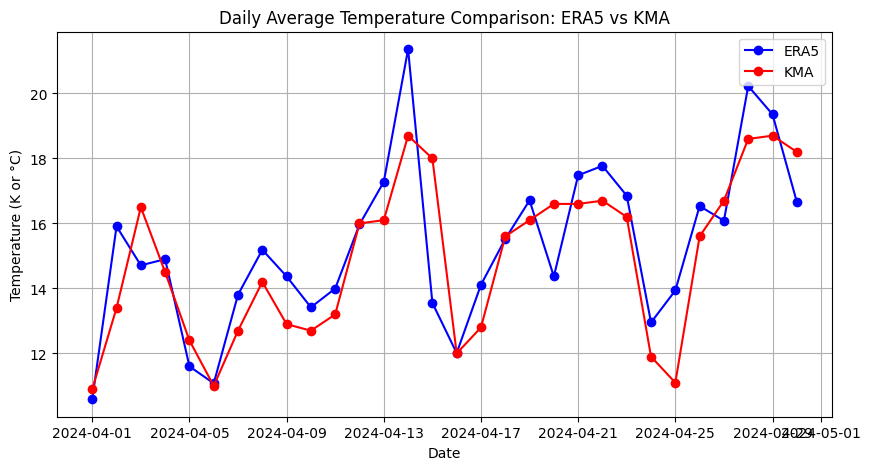

In [ ]:
# 📊 그래프 크기 설정 (가로 10, 세로 5)
plt.figure(figsize=(10, 5))

# 🔵 ERA5 기온 그래프 그리기 (파란색, 선+동그라미 마커)
plt.plot(combined_df.index, combined_df['ERA5'],
         c='blue', label='ERA5',
         linestyle='-', marker='o')

# 🔴 기상청(KMA) 기온 그래프 그리기 (빨간색, 선+동그라미 마커)
plt.plot(combined_df.index, combined_df['KMA'],
         c='red', label='KMA',
         linestyle='-', marker='o')

plt.xlabel('Date') # 🗓 x축 라벨 설정 (날짜)
plt.ylabel('Temperature (K or °C)') # 🌡 y축 라벨 설정 (온도 단위)
plt.title('Daily Average Temperature Comparison: ERA5 vs KMA') # 📌 그래프 제목 설정
plt.grid()# 🔲 격자 표시
plt.legend() # 🧾 범례(ERA5 / KMA 라벨) 표시
plt.show() # 🖼 그래프 보여주기
